In [15]:
# kNN_direct_binary.py - 直接读取二进制MNIST文件
import struct
import numpy as np
import operator
from os import listdir
import time

def load_mnist_images(filename):
    """直接加载MNIST图像数据"""
    with open(filename, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        print(f"加载图像: {filename}, 数量: {num}, 尺寸: {rows}x{cols}")
        
        images = np.fromfile(f, dtype=np.uint8).reshape(num, rows, cols)
        return images

def load_mnist_labels(filename):
    """直接加载MNIST标签数据"""
    with open(filename, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        print(f"加载标签: {filename}, 数量: {num}")
        
        labels = np.fromfile(f, dtype=np.uint8)
        return labels

def preprocess_image(image):
    """预处理单个图像：调整尺寸并二值化"""
    # 将28x28填充为32x32
    padded_image = np.zeros((32, 32), dtype=np.uint8)
    start_row = (32 - 28) // 2
    start_col = (32 - 28) // 2
    padded_image[start_row:start_row+28, start_col:start_col+28] = image
    
    # 二值化并展平为向量
    binary_vector = (padded_image > 127).astype(int).flatten()
    return binary_vector

def classify0(inX, dataSet, labels, k):
    """kNN分类器"""
    dataSetSize = dataSet.shape[0]
    diffMat = np.tile(inX, (dataSetSize, 1)) - dataSet
    sqDiffMat = diffMat ** 2
    sqDistances = sqDiffMat.sum(axis=1)
    distances = sqDistances ** 0.5
    sortedDistIndicies = distances.argsort()
    
    classCount = {}
    for i in range(k):
        voteIlabel = labels[sortedDistIndicies[i]]
        classCount[voteIlabel] = classCount.get(voteIlabel, 0) + 1
    
    sortedClassCount = sorted(classCount.items(), key=operator.itemgetter(1), reverse=True)
    return sortedClassCount[0][0]

def kNN_mnist_direct():
    """直接使用二进制MNIST数据进行kNN分类"""
    print("=== 直接使用MNIST二进制数据 ===")
    
    # 加载训练数据
    print("加载训练数据...")
    train_start = time.time()
    train_images = load_mnist_images('train-images.idx3-ubyte')
    train_labels = load_mnist_labels('train-labels.idx1-ubyte')
    
    # 预处理训练数据
    print("预处理训练数据...")
    num_train = 1000  # 使用1000个训练样本（可根据需要调整）
    trainingMat = np.zeros((num_train, 1024))
    processed_labels = []
    
    for i in range(num_train):
        trainingMat[i] = preprocess_image(train_images[i])
        processed_labels.append(train_labels[i])
        
        if (i + 1) % 200 == 0:
            print(f"已预处理 {i + 1} 个训练样本")
    
    train_time = time.time() - train_start
    print(f"训练数据加载完成，耗时: {train_time:.2f}秒")
    
    # 加载测试数据
    print("加载测试数据...")
    test_images = load_mnist_images('t10k-images.idx3-ubyte')
    test_labels = load_mnist_labels('t10k-labels.idx1-ubyte')
    
    # 测试
    errorCount = 0.0
    num_test = 200  # 使用200个测试样本
    
    print(f"开始测试，使用 {num_test} 个测试样本...")
    test_start = time.time()
    
    for i in range(num_test):
        test_vector = preprocess_image(test_images[i])
        true_label = test_labels[i]
        
        # 使用kNN分类
        predicted_label = classify0(test_vector, trainingMat, processed_labels, 3)
        
        result_str = f"测试样本 {i+1}/{num_test}: 预测={predicted_label}, 实际={true_label}"
        
        if predicted_label != true_label:
            errorCount += 1.0
            print(result_str + " --- 错误!")
        else:
            if (i + 1) % 20 == 0:
                print(result_str + " --- 正确")
        
        if (i + 1) % 50 == 0:
            current_accuracy = (1 - errorCount/(i+1)) * 100
            print(f"进度: {i+1}/{num_test}, 当前准确率: {current_accuracy:.2f}%")
    
    total_time = time.time() - test_start
    print(f"\n=== 最终结果 ===")
    print(f"总错误数: {int(errorCount)}")
    print(f"总测试样本数: {num_test}")
    print(f"错误率: {errorCount/float(num_test):.6f}")
    print(f"准确率: {(1 - errorCount/float(num_test)) * 100:.2f}%")
    print(f"测试耗时: {total_time:.2f}秒")

if __name__ == '__main__':
    kNN_mnist_direct()

=== 直接使用MNIST二进制数据 ===
加载训练数据...
加载图像: train-images.idx3-ubyte, 数量: 60000, 尺寸: 28x28
加载标签: train-labels.idx1-ubyte, 数量: 60000
预处理训练数据...
已预处理 200 个训练样本
已预处理 400 个训练样本
已预处理 600 个训练样本
已预处理 800 个训练样本
已预处理 1000 个训练样本
训练数据加载完成，耗时: 0.12秒
加载测试数据...
加载图像: t10k-images.idx3-ubyte, 数量: 10000, 尺寸: 28x28
加载标签: t10k-labels.idx1-ubyte, 数量: 10000
开始测试，使用 200 个测试样本...
测试样本 9/200: 预测=4, 实际=5 --- 错误!
测试样本 12/200: 预测=0, 实际=6 --- 错误!
测试样本 20/200: 预测=9, 实际=4 --- 错误!
测试样本 23/200: 预测=1, 实际=6 --- 错误!
测试样本 25/200: 预测=9, 实际=4 --- 错误!
测试样本 40/200: 预测=1, 实际=1 --- 正确
测试样本 44/200: 预测=1, 实际=2 --- 错误!
测试样本 45/200: 预测=5, 实际=3 --- 错误!
测试样本 46/200: 预测=3, 实际=5 --- 错误!
进度: 50/200, 当前准确率: 84.00%
测试样本 55/200: 预测=0, 实际=6 --- 错误!
测试样本 60/200: 预测=1, 实际=5 --- 错误!
测试样本 62/200: 预测=2, 实际=8 --- 错误!
测试样本 63/200: 预测=4, 实际=9 --- 错误!
测试样本 64/200: 预测=9, 实际=3 --- 错误!
测试样本 66/200: 预测=9, 实际=4 --- 错误!
测试样本 67/200: 预测=0, 实际=6 --- 错误!
测试样本 74/200: 预测=7, 实际=9 --- 错误!
测试样本 78/200: 预测=3, 实际=2 --- 错误!
测试样本 80/200: 预测=7, 实际=7 --- 正确
测试样本 81/200: 预测

In [16]:
# kNN_sklearn_direct.py - 使用sklearn直接处理二进制数据
import struct
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

def load_mnist_images(filename):
    """加载MNIST图像数据"""
    with open(filename, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        print(f"加载图像: {filename}, 数量: {num}, 尺寸: {rows}x{cols}")
        
        images = np.fromfile(f, dtype=np.uint8).reshape(num, rows, cols)
        return images

def load_mnist_labels(filename):
    """加载MNIST标签数据"""
    with open(filename, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        print(f"加载标签: {filename}, 数量: {num}")
        
        labels = np.fromfile(f, dtype=np.uint8)
        return labels

def preprocess_images(images):
    """批量预处理图像"""
    num_images = images.shape[0]
    processed = np.zeros((num_images, 1024))
    
    for i in range(num_images):
        # 将28x28填充为32x32
        padded_image = np.zeros((32, 32), dtype=np.uint8)
        start_row = (32 - 28) // 2
        start_col = (32 - 28) // 2
        padded_image[start_row:start_row+28, start_col:start_col+28] = images[i]
        
        # 二值化并展平
        processed[i] = (padded_image > 127).astype(int).flatten()
    
    return processed

def kNN_sklearn_mnist():
    """使用sklearn直接处理MNIST二进制数据"""
    print("=== 使用sklearn处理MNIST二进制数据 ===")
    
    # 加载数据
    print("加载数据...")
    train_images = load_mnist_images('train-images.idx3-ubyte')
    train_labels = load_mnist_labels('train-labels.idx1-ubyte')
    test_images = load_mnist_images('t10k-images.idx3-ubyte')
    test_labels = load_mnist_labels('t10k-labels.idx1-ubyte')
    
    # 预处理
    print("预处理数据...")
    num_train = 2000
    num_test = 500
    
    X_train = preprocess_images(train_images[:num_train])
    y_train = train_labels[:num_train]
    X_test = preprocess_images(test_images[:num_test])
    y_test = test_labels[:num_test]
    
    print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")
    
    # 创建并训练kNN模型
    print("训练kNN模型...")
    knn = KNeighborsClassifier(n_neighbors=3)
    
    train_start = time.time()
    knn.fit(X_train, y_train)
    train_time = time.time() - train_start
    print(f"模型训练完成，耗时: {train_time:.2f}秒")
    
    # 预测
    print("进行预测...")
    test_start = time.time()
    y_pred = knn.predict(X_test)
    test_time = time.time() - test_start
    
    # 评估结果
    accuracy = accuracy_score(y_test, y_pred)
    error_count = np.sum(y_pred != y_test)
    
    print(f"\n=== 最终结果 ===")
    print(f"总错误数: {error_count}")
    print(f"总测试样本数: {num_test}")
    print(f"错误率: {error_count/float(num_test):.6f}")
    print(f"准确率: {accuracy * 100:.2f}%")
    print(f"测试耗时: {test_time:.2f}秒")
    
    # 显示一些错误分类的样本
    print(f"\n前10个错误分类的样本:")
    error_indices = np.where(y_pred != y_test)[0][:10]
    for idx in error_indices:
        print(f"  样本 {idx}: 预测={y_pred[idx]}, 实际={y_test[idx]}")

if __name__ == '__main__':
    kNN_sklearn_mnist()

=== 使用sklearn处理MNIST二进制数据 ===
加载数据...
加载图像: train-images.idx3-ubyte, 数量: 60000, 尺寸: 28x28
加载标签: train-labels.idx1-ubyte, 数量: 60000
加载图像: t10k-images.idx3-ubyte, 数量: 10000, 尺寸: 28x28
加载标签: t10k-labels.idx1-ubyte, 数量: 10000
预处理数据...
训练集: (2000, 1024), 测试集: (500, 1024)
训练kNN模型...
模型训练完成，耗时: 0.01秒
进行预测...

=== 最终结果 ===
总错误数: 80
总测试样本数: 500
错误率: 0.160000
准确率: 84.00%
测试耗时: 1.62秒

前10个错误分类的样本:
  样本 4: 预测=9, 实际=4
  样本 8: 预测=4, 实际=5
  样本 18: 预测=2, 实际=3
  样本 43: 预测=1, 实际=2
  样本 45: 预测=3, 实际=5
  样本 47: 预测=1, 实际=2
  样本 54: 预测=0, 实际=6
  样本 59: 预测=1, 实际=5
  样本 73: 预测=7, 实际=9
  样本 77: 预测=7, 实际=2


In [23]:
# kNN_improved.py - Improved Manual kNN Implementation
import struct
import numpy as np
import operator
import time
from collections import Counter

def load_mnist_images(filename):
    """Load MNIST image data"""
    with open(filename, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        print(f"Loading images: {filename}, count: {num}, size: {rows}x{cols}")
        images = np.fromfile(f, dtype=np.uint8).reshape(num, rows, cols)
        return images

def load_mnist_labels(filename):
    """Load MNIST label data"""
    with open(filename, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        print(f"Loading labels: {filename}, count: {num}")
        labels = np.fromfile(f, dtype=np.uint8)
        return labels

def preprocess_image_improved(image):
    """Improved preprocessing: better normalization and feature extraction"""
    # Convert 28x28 to 32x32 with padding
    padded_image = np.zeros((32, 32), dtype=np.float32)
    start_row = (32 - 28) // 2
    start_col = (32 - 28) // 2
    padded_image[start_row:start_row+28, start_col:start_col+28] = image
    
    # Improved binarization with adaptive threshold
    normalized = padded_image / 255.0
    
    # Apply slight Gaussian blur to reduce noise (simulated with averaging)
    blurred = np.zeros((32, 32), dtype=np.float32)
    for i in range(1, 31):
        for j in range(1, 31):
            blurred[i, j] = np.mean(normalized[i-1:i+2, j-1:j+2])
    
    # Use more sophisticated binarization
    binary_vector = (blurred > 0.3).astype(int).flatten()
    
    return binary_vector

def preprocess_images_improved(images):
    """Batch preprocess images with improved method"""
    num_images = images.shape[0]
    processed = np.zeros((num_images, 1024))
    
    for i in range(num_images):
        processed[i] = preprocess_image_improved(images[i])
    
    return processed

def classify0(inX, dataSet, labels, k):
    """kNN classifier"""
    dataSetSize = dataSet.shape[0]
    
    # Calculate Euclidean distance
    diffMat = np.tile(inX, (dataSetSize, 1)) - dataSet
    sqDiffMat = diffMat ** 2
    sqDistances = sqDiffMat.sum(axis=1)
    distances = sqDistances ** 0.5
    
    # Sort distances
    sortedDistIndicies = distances.argsort()
    
    # Count classes of k nearest neighbors
    classCount = {}
    for i in range(k):
        voteIlabel = labels[sortedDistIndicies[i]]
        classCount[voteIlabel] = classCount.get(voteIlabel, 0) + 1
    
    # Return the class with highest frequency
    sortedClassCount = sorted(classCount.items(), 
                             key=operator.itemgetter(1), reverse=True)
    return sortedClassCount[0][0]

def kNN_handwritten_test_improved():
    """Test handwritten digit recognition with improved preprocessing"""
    print("=== Improved kNN Handwritten Digit Recognition ===")
    
    # Load data
    print("Loading MNIST dataset...")
    train_images = load_mnist_images('train-images.idx3-ubyte')
    train_labels = load_mnist_labels('train-labels.idx1-ubyte')
    test_images = load_mnist_images('t10k-images.idx3-ubyte')
    test_labels = load_mnist_labels('t10k-labels.idx1-ubyte')
    
    # Preprocess training data with improved method
    print("Preprocessing training data...")
    num_train = 3000
    trainingMat = np.zeros((num_train, 1024))
    processed_labels = []
    
    for i in range(num_train):
        trainingMat[i] = preprocess_image_improved(train_images[i])
        processed_labels.append(train_labels[i])
        
        if (i + 1) % 500 == 0:
            print(f"Processed {i + 1} training samples")
    
    print(f"Training data loaded: {num_train} samples")
    
    # Test
    errorCount = 0.0
    num_test = 500
    
    print(f"Starting test with {num_test} samples...")
    test_start = time.time()
    
    for i in range(num_test):
        test_vector = preprocess_image_improved(test_images[i])
        true_label = test_labels[i]
        
        # Use kNN classification with k=3
        predicted_label = classify0(test_vector, trainingMat, processed_labels, 3)
        
        result_str = f"Test sample {i+1}/{num_test}: Predicted={predicted_label}, Actual={true_label}"
        
        if predicted_label != true_label:
            errorCount += 1.0
            print(result_str + " --- ERROR!")
        else:
            if (i + 1) % 50 == 0:  # Show every 50 correct samples
                print(result_str + " --- CORRECT")
        
        if (i + 1) % 100 == 0:
            current_accuracy = (1 - errorCount/(i+1)) * 100
            print(f"Progress: {i+1}/{num_test}, Current accuracy: {current_accuracy:.2f}%")
    
    total_time = time.time() - test_start
    print(f"\n=== Final Results ===")
    print(f"Total errors: {int(errorCount)}")
    print(f"Total test samples: {num_test}")
    print(f"Error rate: {errorCount/float(num_test):.6f}")
    print(f"Accuracy: {(1 - errorCount/float(num_test)) * 100:.2f}%")
    print(f"Test time: {total_time:.2f} seconds")
    print(f"Average time per sample: {total_time/num_test*1000:.2f} ms")

if __name__ == '__main__':
    kNN_handwritten_test_improved()

=== Improved kNN Handwritten Digit Recognition ===
Loading MNIST dataset...
Loading images: train-images.idx3-ubyte, count: 60000, size: 28x28
Loading labels: train-labels.idx1-ubyte, count: 60000
Loading images: t10k-images.idx3-ubyte, count: 10000, size: 28x28
Loading labels: t10k-labels.idx1-ubyte, count: 10000
Preprocessing training data...
Processed 500 training samples
Processed 1000 training samples
Processed 1500 training samples
Processed 2000 training samples
Processed 2500 training samples
Processed 3000 training samples
Training data loaded: 3000 samples
Starting test with 500 samples...
Test sample 9/500: Predicted=4, Actual=5 --- ERROR!
Test sample 45/500: Predicted=5, Actual=3 --- ERROR!
Test sample 50/500: Predicted=4, Actual=4 --- CORRECT
Test sample 62/500: Predicted=2, Actual=8 --- ERROR!
Test sample 78/500: Predicted=7, Actual=2 --- ERROR!
Test sample 81/500: Predicted=9, Actual=7 --- ERROR!
Test sample 100/500: Predicted=9, Actual=9 --- CORRECT
Progress: 100/500, C

In [24]:
# kNN_SK_improved.py - Improved sklearn kNN Implementation
import struct
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

def load_mnist_images(filename):
    """Load MNIST image data"""
    with open(filename, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        print(f"Loading images: {filename}, count: {num}, size: {rows}x{cols}")
        images = np.fromfile(f, dtype=np.uint8).reshape(num, rows, cols)
        return images

def load_mnist_labels(filename):
    """Load MNIST label data"""
    with open(filename, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        print(f"Loading labels: {filename}, count: {num}")
        labels = np.fromfile(f, dtype=np.uint8)
        return labels

def preprocess_image_improved(image):
    """Improved preprocessing: better normalization and feature extraction"""
    # Convert 28x28 to 32x32 with padding
    padded_image = np.zeros((32, 32), dtype=np.float32)
    start_row = (32 - 28) // 2
    start_col = (32 - 28) // 2
    padded_image[start_row:start_row+28, start_col:start_col+28] = image
    
    # Improved binarization with adaptive threshold
    normalized = padded_image / 255.0
    
    # Apply slight Gaussian blur to reduce noise (simulated with averaging)
    blurred = np.zeros((32, 32), dtype=np.float32)
    for i in range(1, 31):
        for j in range(1, 31):
            blurred[i, j] = np.mean(normalized[i-1:i+2, j-1:j+2])
    
    # Use more sophisticated binarization
    binary_vector = (blurred > 0.3).astype(int).flatten()
    
    return binary_vector

def preprocess_images_improved(images):
    """Batch preprocess images with improved method"""
    num_images = images.shape[0]
    processed = np.zeros((num_images, 1024))
    
    for i in range(num_images):
        processed[i] = preprocess_image_improved(images[i])
    
    return processed

def kNN_sklearn_improved():
    """Test handwritten digit recognition with sklearn and improved preprocessing"""
    print("=== Improved sklearn kNN Handwritten Digit Recognition ===")
    
    # Load data
    print("Loading MNIST dataset...")
    train_images = load_mnist_images('train-images.idx3-ubyte')
    train_labels = load_mnist_labels('train-labels.idx1-ubyte')
    test_images = load_mnist_images('t10k-images.idx3-ubyte')
    test_labels = load_mnist_labels('t10k-labels.idx1-ubyte')
    
    # Preprocess data with improved method
    print("Preprocessing data...")
    num_train = 3000
    num_test = 500
    
    X_train = preprocess_images_improved(train_images[:num_train])
    y_train = train_labels[:num_train]
    X_test = preprocess_images_improved(test_images[:num_test])
    y_test = test_labels[:num_test]
    
    print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
    
    # Create kNN classifier with optimized parameters
    knn = KNeighborsClassifier(
        n_neighbors=3,
        weights='distance',  # Use distance-based weighting
        algorithm='auto',
        n_jobs=-1  # Use all CPU cores
    )
    
    # Train model
    print("Training model...")
    train_start = time.time()
    knn.fit(X_train, y_train)
    train_time = time.time() - train_start
    print(f"Model training completed, time: {train_time:.2f} seconds")
    
    # Test
    errorCount = 0.0
    print(f"Starting test with {num_test} samples...")
    test_start = time.time()
    
    for i in range(num_test):
        test_vector = X_test[i].reshape(1, -1)
        true_label = y_test[i]
        
        # Use sklearn kNN for prediction
        predicted_label = knn.predict(test_vector)[0]
        
        result_str = f"Test sample {i+1}/{num_test}: Predicted={predicted_label}, Actual={true_label}"
        
        if predicted_label != true_label:
            errorCount += 1.0
            print(result_str + " --- ERROR!")
        else:
            if (i + 1) % 50 == 0:  # Show every 50 correct samples
                print(result_str + " --- CORRECT")
        
        if (i + 1) % 100 == 0:
            current_accuracy = (1 - errorCount/(i+1)) * 100
            print(f"Progress: {i+1}/{num_test}, Current accuracy: {current_accuracy:.2f}%")
    
    total_time = time.time() - test_start
    
    # Calculate accuracy using sklearn (for verification)
    y_pred = knn.predict(X_test)
    sklearn_accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\n=== Final Results ===")
    print(f"Total errors: {int(errorCount)}")
    print(f"Total test samples: {num_test}")
    print(f"Error rate: {errorCount/float(num_test):.6f}")
    print(f"Accuracy (manual): {(1 - errorCount/float(num_test)) * 100:.2f}%")
    print(f"Accuracy (sklearn): {sklearn_accuracy * 100:.2f}%")
    print(f"Test time: {total_time:.2f} seconds")
    print(f"Average time per sample: {total_time/num_test*1000:.2f} ms")
    
    # Show some misclassified examples
    error_indices = np.where(y_pred != y_test)[0]
    if len(error_indices) > 0:
        print(f"\nMisclassification examples (first 5):")
        for i in error_indices[:5]:
            print(f"  Sample {i}: Predicted={y_pred[i]}, Actual={y_test[i]}")

if __name__ == '__main__':
    kNN_sklearn_improved()

=== Improved sklearn kNN Handwritten Digit Recognition ===
Loading MNIST dataset...
Loading images: train-images.idx3-ubyte, count: 60000, size: 28x28
Loading labels: train-labels.idx1-ubyte, count: 60000
Loading images: t10k-images.idx3-ubyte, count: 10000, size: 28x28
Loading labels: t10k-labels.idx1-ubyte, count: 10000
Preprocessing data...
Training set: (3000, 1024), Test set: (500, 1024)
Training model...
Model training completed, time: 0.01 seconds
Starting test with 500 samples...
Test sample 9/500: Predicted=4, Actual=5 --- ERROR!
Test sample 45/500: Predicted=5, Actual=3 --- ERROR!
Test sample 50/500: Predicted=4, Actual=4 --- CORRECT
Test sample 62/500: Predicted=2, Actual=8 --- ERROR!
Test sample 78/500: Predicted=7, Actual=2 --- ERROR!
Test sample 81/500: Predicted=9, Actual=7 --- ERROR!
Test sample 100/500: Predicted=9, Actual=9 --- CORRECT
Progress: 100/500, Current accuracy: 95.00%
Test sample 116/500: Predicted=9, Actual=4 --- ERROR!
Test sample 150/500: Predicted=2, Ac

=== kNN k Value Comparison Experiment ===
Loading MNIST dataset...
Loading images: train-images.idx3-ubyte, count: 60000, size: 28x28
Loading labels: train-labels.idx1-ubyte, count: 60000
Loading images: t10k-images.idx3-ubyte, count: 10000, size: 28x28
Loading labels: t10k-labels.idx1-ubyte, count: 10000
Preprocessing data...
Training set: (3000, 1024), Test set: (1000, 1024)

Starting k value comparison experiment...
k	Accuracy(%)	Train Time(s)	Predict Time(s)	Total Time(s)
-----------------------------------------------------------------
1	85.60		0.0000		0.0695		0.0695
2	85.20		0.0080		0.0693		0.0773
3	85.90		0.0082		0.0666		0.0748
4	85.90		0.0000		0.0682		0.0682
5	86.10		0.0076		0.0665		0.0741
6	85.40		0.0086		0.0664		0.0751
7	85.70		0.0002		0.0731		0.0733
8	85.70		0.0000		0.0717		0.0717
9	85.60		0.0080		0.0634		0.0714
10	85.00		0.0086		0.0618		0.0703
11	85.10		0.0000		0.0760		0.0760
13	84.30		0.0081		0.0671		0.0752
15	84.80		0.0062		0.0713		0.0775


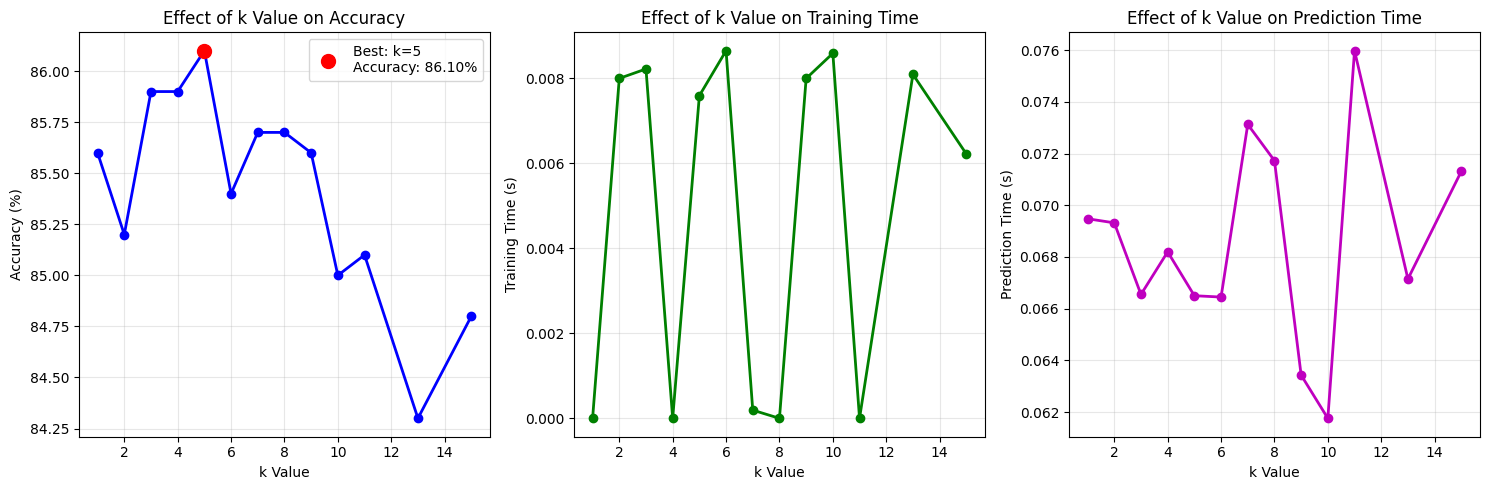


=== Detailed Analysis for Best k Value (k=5) ===
Accuracy: 86.10%
Error Count: 139/1000
Error Rate: 13.90%

Accuracy for Each Digit:
  Digit 0: 98.82%
  Digit 1: 100.00%
  Digit 2: 68.10%
  Digit 3: 85.98%
  Digit 4: 90.00%
  Digit 5: 82.76%
  Digit 6: 94.25%
  Digit 7: 85.86%
  Digit 8: 65.17%
  Digit 9: 89.36%


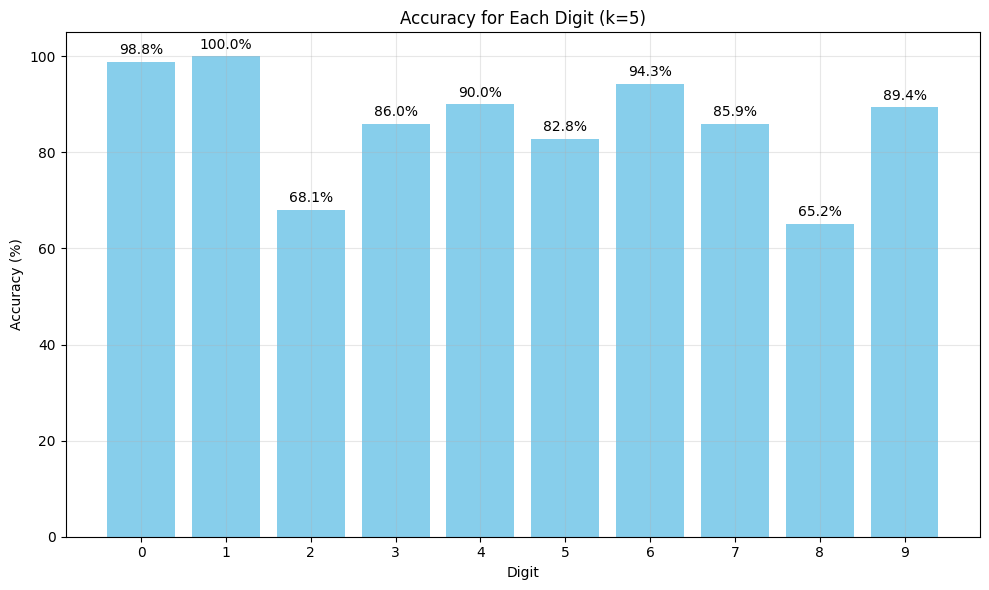


Misclassification Analysis (First 10):
  Sample 8: Predicted=4, Actual=5
  Sample 43: Predicted=1, Actual=2
  Sample 44: Predicted=1, Actual=3
  Sample 45: Predicted=3, Actual=5
  Sample 47: Predicted=1, Actual=2
  Sample 59: Predicted=1, Actual=5
  Sample 62: Predicted=4, Actual=9
  Sample 73: Predicted=7, Actual=9
  Sample 77: Predicted=7, Actual=2
  Sample 80: Predicted=9, Actual=7

=== Experiment Results Summary ===
k	Accuracy(%)	Train Time(s)	Predict Time(s)	Total Time(s)
-----------------------------------------------------------------
1	85.60		0.0000		0.0695		0.0695
2	85.20		0.0080		0.0693		0.0773
3	85.90		0.0082		0.0666		0.0748
4	85.90		0.0000		0.0682		0.0682
5 ★	86.10		0.0076		0.0665		0.0741
6	85.40		0.0086		0.0664		0.0751
7	85.70		0.0002		0.0731		0.0733
8	85.70		0.0000		0.0717		0.0717
9	85.60		0.0080		0.0634		0.0714
10	85.00		0.0086		0.0618		0.0703
11	85.10		0.0000		0.0760		0.0760
13	84.30		0.0081		0.0671		0.0752
15	84.80		0.0062		0.0713		0.0775

=== Experiment Summary ===
B

In [21]:
# k_tuning_comparison.py - k Value Tuning Comparison Experiment
import struct
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time
import matplotlib.pyplot as plt

def load_mnist_images(filename):
    """Load MNIST image data"""
    with open(filename, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        print(f"Loading images: {filename}, count: {num}, size: {rows}x{cols}")
        images = np.fromfile(f, dtype=np.uint8).reshape(num, rows, cols)
        return images

def load_mnist_labels(filename):
    """Load MNIST label data"""
    with open(filename, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        print(f"Loading labels: {filename}, count: {num}")
        labels = np.fromfile(f, dtype=np.uint8)
        return labels

def preprocess_image(image):
    """Preprocess single image: resize and binarize"""
    # Convert 28x28 to 32x32 with padding
    padded_image = np.zeros((32, 32), dtype=np.uint8)
    start_row = (32 - 28) // 2
    start_col = (32 - 28) // 2
    padded_image[start_row:start_row+28, start_col:start_col+28] = image
    
    # Binarize and flatten to vector
    binary_vector = (padded_image > 127).astype(int).flatten()
    return binary_vector

def preprocess_images(images):
    """Batch preprocess images"""
    num_images = images.shape[0]
    processed = np.zeros((num_images, 1024))
    
    for i in range(num_images):
        processed[i] = preprocess_image(images[i])
    
    return processed

def k_value_comparison():
    """k Value Comparison Experiment"""
    print("=== kNN k Value Comparison Experiment ===")
    
    # Load data
    print("Loading MNIST dataset...")
    train_images = load_mnist_images('train-images.idx3-ubyte')
    train_labels = load_mnist_labels('train-labels.idx1-ubyte')
    test_images = load_mnist_images('t10k-images.idx3-ubyte')
    test_labels = load_mnist_labels('t10k-labels.idx1-ubyte')
    
    # Preprocess data
    print("Preprocessing data...")
    num_train = 3000
    num_test = 1000
    
    X_train = preprocess_images(train_images[:num_train])
    y_train = train_labels[:num_train]
    X_test = preprocess_images(test_images[:num_test])
    y_test = test_labels[:num_test]
    
    print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
    
    # Test different k values
    k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 15]
    results = []
    
    print("\nStarting k value comparison experiment...")
    print("k\tAccuracy(%)\tTrain Time(s)\tPredict Time(s)\tTotal Time(s)")
    print("-" * 65)
    
    for k in k_values:
        # Create kNN classifier
        knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
        
        # Train model
        train_start = time.time()
        knn.fit(X_train, y_train)
        train_time = time.time() - train_start
        
        # Predict
        predict_start = time.time()
        y_pred = knn.predict(X_test)
        predict_time = time.time() - predict_start
        
        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)
        total_time = train_time + predict_time
        
        # Store results
        results.append({
            'k': k,
            'accuracy': accuracy,
            'train_time': train_time,
            'predict_time': predict_time,
            'total_time': total_time
        })
        
        print(f"{k}\t{accuracy*100:.2f}\t\t{train_time:.4f}\t\t{predict_time:.4f}\t\t{total_time:.4f}")
    
    return results, X_test, y_test, X_train, y_train

def plot_comparison_results(results):
    """Plot k value comparison results"""
    k_values = [r['k'] for r in results]
    accuracies = [r['accuracy'] * 100 for r in results]
    train_times = [r['train_time'] for r in results]
    predict_times = [r['predict_time'] for r in results]
    
    # Find best k value
    best_idx = np.argmax(accuracies)
    best_k = k_values[best_idx]
    best_accuracy = accuracies[best_idx]
    
    # Create plots
    plt.figure(figsize=(15, 5))
    
    # Accuracy plot
    plt.subplot(1, 3, 1)
    plt.plot(k_values, accuracies, 'bo-', linewidth=2, markersize=6)
    plt.plot(best_k, best_accuracy, 'ro', markersize=10, label=f'Best: k={best_k}\nAccuracy: {best_accuracy:.2f}%')
    plt.xlabel('k Value')
    plt.ylabel('Accuracy (%)')
    plt.title('Effect of k Value on Accuracy')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Training time plot
    plt.subplot(1, 3, 2)
    plt.plot(k_values, train_times, 'go-', linewidth=2, markersize=6)
    plt.xlabel('k Value')
    plt.ylabel('Training Time (s)')
    plt.title('Effect of k Value on Training Time')
    plt.grid(True, alpha=0.3)
    
    # Prediction time plot
    plt.subplot(1, 3, 3)
    plt.plot(k_values, predict_times, 'mo-', linewidth=2, markersize=6)
    plt.xlabel('k Value')
    plt.ylabel('Prediction Time (s)')
    plt.title('Effect of k Value on Prediction Time')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('k_value_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return best_k, best_accuracy

def analyze_best_k_results(best_k, X_train, y_train, X_test, y_test):
    """Analyze detailed results for the best k value"""
    print(f"\n=== Detailed Analysis for Best k Value (k={best_k}) ===")
    
    # Train model with best k
    knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    # Calculate detailed metrics
    accuracy = accuracy_score(y_test, y_pred)
    error_count = np.sum(y_pred != y_test)
    
    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"Error Count: {error_count}/{len(y_test)}")
    print(f"Error Rate: {error_count/len(y_test)*100:.2f}%")
    
    # Calculate accuracy for each digit
    print(f"\nAccuracy for Each Digit:")
    digit_accuracies = []
    for digit in range(10):
        digit_indices = y_test == digit
        if np.sum(digit_indices) > 0:
            digit_accuracy = np.mean(y_pred[digit_indices] == digit)
            digit_accuracies.append(digit_accuracy)
            print(f"  Digit {digit}: {digit_accuracy*100:.2f}%")
    
    # Plot accuracy for each digit
    plt.figure(figsize=(10, 6))
    plt.bar(range(10), [acc*100 for acc in digit_accuracies], color='skyblue')
    plt.xlabel('Digit')
    plt.ylabel('Accuracy (%)')
    plt.title(f'Accuracy for Each Digit (k={best_k})')
    plt.xticks(range(10))
    plt.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, acc in enumerate(digit_accuracies):
        plt.text(i, acc*100 + 1, f'{acc*100:.1f}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('digit_accuracy.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Analyze misclassifications
    error_indices = np.where(y_pred != y_test)[0]
    print(f"\nMisclassification Analysis (First 10):")
    error_samples = []
    for i in error_indices[:10]:
        error_samples.append({
            'index': i,
            'predicted': y_pred[i],
            'actual': y_test[i]
        })
        print(f"  Sample {i}: Predicted={y_pred[i]}, Actual={y_test[i]}")
    
    return accuracy, error_samples

def print_summary_table(results, best_k):
    """Print summary table of results"""
    print(f"\n=== Experiment Results Summary ===")
    print("k\tAccuracy(%)\tTrain Time(s)\tPredict Time(s)\tTotal Time(s)")
    print("-" * 65)
    
    for result in results:
        k = result['k']
        accuracy = result['accuracy'] * 100
        train_time = result['train_time']
        predict_time = result['predict_time']
        total_time = result['total_time']
        
        # Mark best result
        marker = " ★" if k == best_k else ""
        
        print(f"{k}{marker}\t{accuracy:.2f}\t\t{train_time:.4f}\t\t{predict_time:.4f}\t\t{total_time:.4f}")

if __name__ == '__main__':
    # Execute k value comparison experiment
    results, X_test, y_test, X_train, y_train = k_value_comparison()
    
    # Plot comparison results
    best_k, best_accuracy = plot_comparison_results(results)
    
    # Analyze detailed results for best k
    accuracy, error_samples = analyze_best_k_results(best_k, X_train, y_train, X_test, y_test)
    
    # Print summary table
    print_summary_table(results, best_k)
    
    print(f"\n=== Experiment Summary ===")
    print(f"Best k value: {best_k}")
    print(f"Best accuracy: {best_accuracy:.2f}%")
    print(f"Generated charts:")
    print(f"  - k_value_comparison.png: k value comparison results")
    print(f"  - digit_accuracy.png: Accuracy for each digit")


=== Testing with Simple Preprocessing ===
Loading images: train-images.idx3-ubyte, count: 60000, size: 28x28
Loading labels: train-labels.idx1-ubyte, count: 60000
Loading images: t10k-images.idx3-ubyte, count: 10000, size: 28x28
Loading labels: t10k-labels.idx1-ubyte, count: 10000
Simple preprocessing accuracy: 87.80%
Error rate: 12.2000%
=== Improved kNN k Value Comparison Experiment ===
Loading MNIST dataset...
Loading images: train-images.idx3-ubyte, count: 60000, size: 28x28
Loading labels: train-labels.idx1-ubyte, count: 60000
Loading images: t10k-images.idx3-ubyte, count: 10000, size: 28x28
Loading labels: t10k-labels.idx1-ubyte, count: 10000
Preprocessing data with improved method...
Training set: (5000, 1024), Test set: (1000, 1024)

Starting k value comparison experiment...
k	Accuracy(%)	Train Time(s)	Predict Time(s)	Total Time(s)
-----------------------------------------------------------------
1	91.00		0.0086		0.1159		0.1244
2	90.80		0.0097		0.0997		0.1094
3	92.30		0.0064		

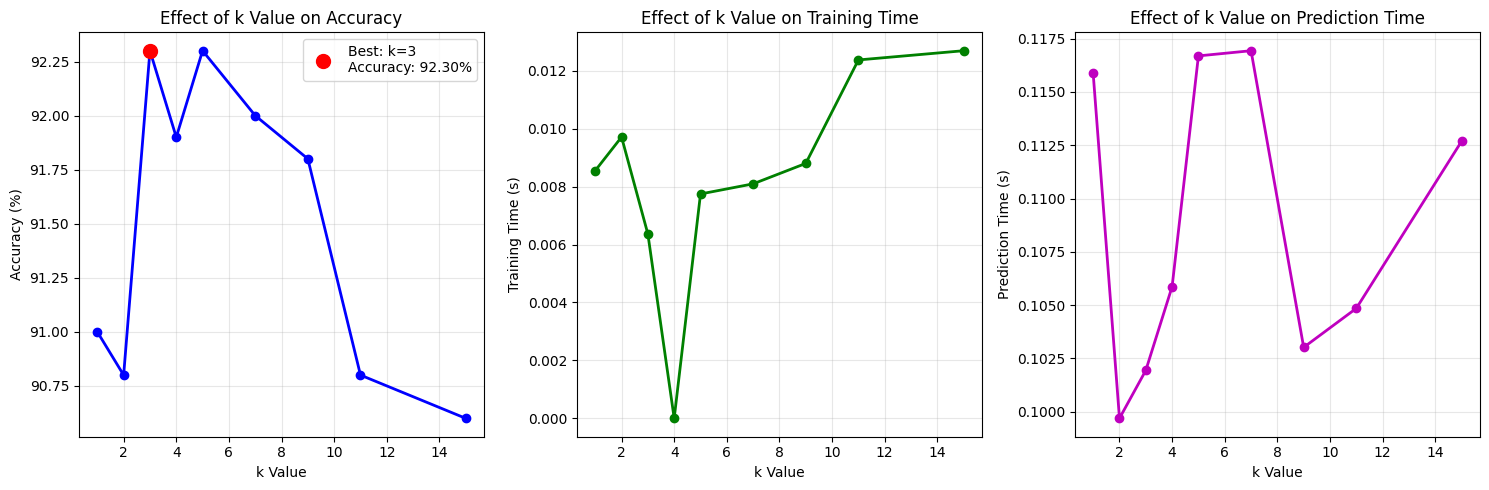


=== Detailed Analysis for Best k Value (k=3) ===
Accuracy: 92.30%
Error Count: 77/1000
Error Rate: 7.7000%

Accuracy for Each Digit:
  Digit 0: 100.00%
  Digit 1: 100.00%
  Digit 2: 88.79%
  Digit 3: 89.72%
  Digit 4: 91.82%
  Digit 5: 89.66%
  Digit 6: 96.55%
  Digit 7: 90.91%
  Digit 8: 82.02%
  Digit 9: 92.55%


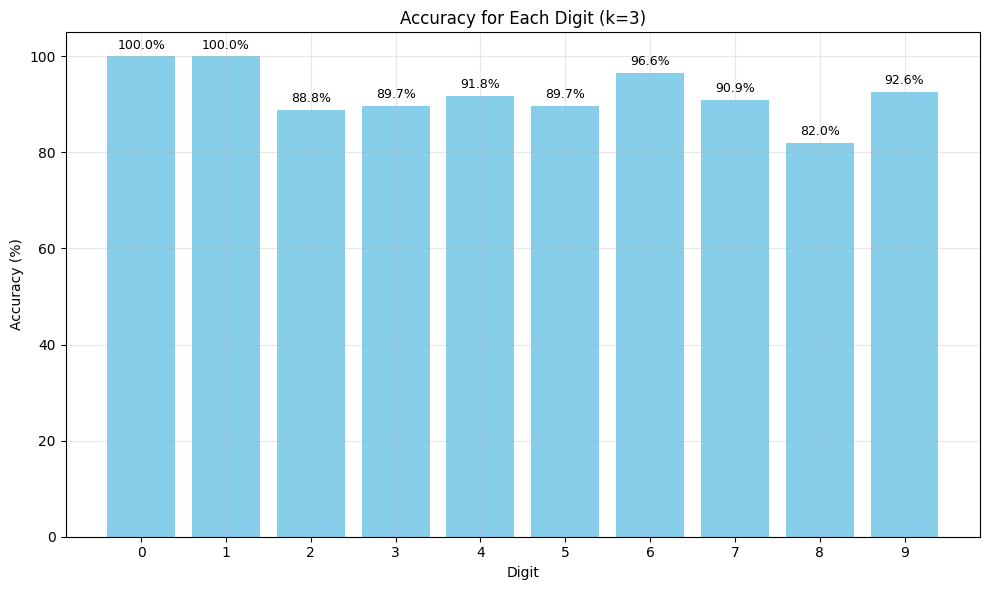


Misclassification Analysis (First 10):
  Sample 24: Predicted=9, Actual=4
  Sample 44: Predicted=5, Actual=3
  Sample 61: Predicted=2, Actual=8
  Sample 77: Predicted=7, Actual=2
  Sample 87: Predicted=5, Actual=3
  Sample 115: Predicted=9, Actual=4
  Sample 151: Predicted=8, Actual=9
  Sample 175: Predicted=1, Actual=7
  Sample 241: Predicted=8, Actual=9
  Sample 242: Predicted=9, Actual=8

=== Experiment Results Summary ===
k	Accuracy(%)	Train Time(s)	Predict Time(s)	Total Time(s)
-----------------------------------------------------------------
1	91.00		0.0086		0.1159		0.1244
2	90.80		0.0097		0.0997		0.1094
3 ★	92.30		0.0064		0.1019		0.1083
4	91.90		0.0000		0.1059		0.1059
5	92.30		0.0077		0.1167		0.1244
7	92.00		0.0081		0.1169		0.1250
9	91.80		0.0088		0.1030		0.1118
11	90.80		0.0124		0.1048		0.1172
15	90.60		0.0127		0.1127		0.1254

=== Experiment Summary ===
Simple preprocessing accuracy: 87.80%
Improved preprocessing accuracy: 92.30%
Best k value: 3
Generated charts:
  - k_value_c

In [22]:
# k_tuning_fixed.py - Fixed k Value Tuning Experiment
import struct
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time
import matplotlib.pyplot as plt

def load_mnist_images(filename):
    """Load MNIST image data"""
    with open(filename, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        print(f"Loading images: {filename}, count: {num}, size: {rows}x{cols}")
        images = np.fromfile(f, dtype=np.uint8).reshape(num, rows, cols)
        return images

def load_mnist_labels(filename):
    """Load MNIST label data"""
    with open(filename, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        print(f"Loading labels: {filename}, count: {num}")
        labels = np.fromfile(f, dtype=np.uint8)
        return labels

def preprocess_image_improved(image):
    """Improved preprocessing: better normalization and feature extraction"""
    # Convert 28x28 to 32x32 with padding
    padded_image = np.zeros((32, 32), dtype=np.float32)
    start_row = (32 - 28) // 2
    start_col = (32 - 28) // 2
    padded_image[start_row:start_row+28, start_col:start_col+28] = image
    
    # Improved binarization with adaptive threshold
    # Instead of simple threshold, use normalized values
    normalized = padded_image / 255.0
    
    # Apply slight Gaussian blur to reduce noise (simulated with averaging)
    # This helps with noisy handwritten digits
    blurred = np.zeros((32, 32), dtype=np.float32)
    for i in range(1, 31):
        for j in range(1, 31):
            blurred[i, j] = np.mean(normalized[i-1:i+2, j-1:j+2])
    
    # Use more sophisticated binarization
    binary_vector = (blurred > 0.3).astype(int).flatten()
    
    return binary_vector

def preprocess_images_improved(images):
    """Batch preprocess images with improved method"""
    num_images = images.shape[0]
    processed = np.zeros((num_images, 1024))
    
    for i in range(num_images):
        processed[i] = preprocess_image_improved(images[i])
    
    return processed

def k_value_comparison_improved():
    """k Value Comparison Experiment with improved preprocessing"""
    print("=== Improved kNN k Value Comparison Experiment ===")
    
    # Load data
    print("Loading MNIST dataset...")
    train_images = load_mnist_images('train-images.idx3-ubyte')
    train_labels = load_mnist_labels('train-labels.idx1-ubyte')
    test_images = load_mnist_images('t10k-images.idx3-ubyte')
    test_labels = load_mnist_labels('t10k-labels.idx1-ubyte')
    
    # Preprocess data with improved method
    print("Preprocessing data with improved method...")
    num_train = 5000  # Increased training size
    num_test = 1000
    
    X_train = preprocess_images_improved(train_images[:num_train])
    y_train = train_labels[:num_train]
    X_test = preprocess_images_improved(test_images[:num_test])
    y_test = test_labels[:num_test]
    
    print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
    
    # Test different k values - focus on smaller k values
    k_values = [1, 2, 3, 4, 5, 7, 9, 11, 15]
    results = []
    
    print("\nStarting k value comparison experiment...")
    print("k\tAccuracy(%)\tTrain Time(s)\tPredict Time(s)\tTotal Time(s)")
    print("-" * 65)
    
    for k in k_values:
        # Create kNN classifier with different distance metrics
        knn = KNeighborsClassifier(
            n_neighbors=k, 
            weights='distance',  # Use distance-based weighting
            algorithm='auto',
            n_jobs=-1
        )
        
        # Train model
        train_start = time.time()
        knn.fit(X_train, y_train)
        train_time = time.time() - train_start
        
        # Predict
        predict_start = time.time()
        y_pred = knn.predict(X_test)
        predict_time = time.time() - predict_start
        
        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)
        total_time = train_time + predict_time
        
        # Store results
        results.append({
            'k': k,
            'accuracy': accuracy,
            'train_time': train_time,
            'predict_time': predict_time,
            'total_time': total_time
        })
        
        print(f"{k}\t{accuracy*100:.2f}\t\t{train_time:.4f}\t\t{predict_time:.4f}\t\t{total_time:.4f}")
    
    return results, X_test, y_test, X_train, y_train

def plot_comparison_results(results):
    """Plot k value comparison results"""
    k_values = [r['k'] for r in results]
    accuracies = [r['accuracy'] * 100 for r in results]
    train_times = [r['train_time'] for r in results]
    predict_times = [r['predict_time'] for r in results]
    
    # Find best k value
    best_idx = np.argmax(accuracies)
    best_k = k_values[best_idx]
    best_accuracy = accuracies[best_idx]
    
    # Create plots
    plt.figure(figsize=(15, 5))
    
    # Accuracy plot
    plt.subplot(1, 3, 1)
    plt.plot(k_values, accuracies, 'bo-', linewidth=2, markersize=6)
    plt.plot(best_k, best_accuracy, 'ro', markersize=10, label=f'Best: k={best_k}\nAccuracy: {best_accuracy:.2f}%')
    plt.xlabel('k Value')
    plt.ylabel('Accuracy (%)')
    plt.title('Effect of k Value on Accuracy')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Training time plot
    plt.subplot(1, 3, 2)
    plt.plot(k_values, train_times, 'go-', linewidth=2, markersize=6)
    plt.xlabel('k Value')
    plt.ylabel('Training Time (s)')
    plt.title('Effect of k Value on Training Time')
    plt.grid(True, alpha=0.3)
    
    # Prediction time plot
    plt.subplot(1, 3, 3)
    plt.plot(k_values, predict_times, 'mo-', linewidth=2, markersize=6)
    plt.xlabel('k Value')
    plt.ylabel('Prediction Time (s)')
    plt.title('Effect of k Value on Prediction Time')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('k_value_comparison_improved.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return best_k, best_accuracy

def analyze_best_k_results(best_k, X_train, y_train, X_test, y_test):
    """Analyze detailed results for the best k value"""
    print(f"\n=== Detailed Analysis for Best k Value (k={best_k}) ===")
    
    # Train model with best k and distance weighting
    knn = KNeighborsClassifier(
        n_neighbors=best_k, 
        weights='distance',
        n_jobs=-1
    )
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    # Calculate detailed metrics
    accuracy = accuracy_score(y_test, y_pred)
    error_count = np.sum(y_pred != y_test)
    
    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"Error Count: {error_count}/{len(y_test)}")
    print(f"Error Rate: {error_count/len(y_test)*100:.4f}%")
    
    # Calculate accuracy for each digit
    print(f"\nAccuracy for Each Digit:")
    digit_accuracies = []
    for digit in range(10):
        digit_indices = y_test == digit
        if np.sum(digit_indices) > 0:
            digit_accuracy = np.mean(y_pred[digit_indices] == digit)
            digit_accuracies.append(digit_accuracy)
            print(f"  Digit {digit}: {digit_accuracy*100:.2f}%")
    
    # Plot accuracy for each digit
    plt.figure(figsize=(10, 6))
    bars = plt.bar(range(10), [acc*100 for acc in digit_accuracies], color='skyblue')
    plt.xlabel('Digit')
    plt.ylabel('Accuracy (%)')
    plt.title(f'Accuracy for Each Digit (k={best_k})')
    plt.xticks(range(10))
    plt.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, acc in enumerate(digit_accuracies):
        plt.text(i, acc*100 + 1, f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('digit_accuracy_improved.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Analyze misclassifications
    error_indices = np.where(y_pred != y_test)[0]
    print(f"\nMisclassification Analysis (First 10):")
    error_samples = []
    for i in error_indices[:10]:
        error_samples.append({
            'index': i,
            'predicted': y_pred[i],
            'actual': y_test[i]
        })
        print(f"  Sample {i}: Predicted={y_pred[i]}, Actual={y_test[i]}")
    
    return accuracy, error_samples

def print_summary_table(results, best_k):
    """Print summary table of results"""
    print(f"\n=== Experiment Results Summary ===")
    print("k\tAccuracy(%)\tTrain Time(s)\tPredict Time(s)\tTotal Time(s)")
    print("-" * 65)
    
    for result in results:
        k = result['k']
        accuracy = result['accuracy'] * 100
        train_time = result['train_time']
        predict_time = result['predict_time']
        total_time = result['total_time']
        
        # Mark best result
        marker = " ★" if k == best_k else ""
        
        print(f"{k}{marker}\t{accuracy:.2f}\t\t{train_time:.4f}\t\t{predict_time:.4f}\t\t{total_time:.4f}")

def test_simple_preprocessing():
    """Test with simpler preprocessing to compare"""
    print("\n=== Testing with Simple Preprocessing ===")
    
    # Load data
    train_images = load_mnist_images('train-images.idx3-ubyte')
    train_labels = load_mnist_labels('train-labels.idx1-ubyte')
    test_images = load_mnist_images('t10k-images.idx3-ubyte')
    test_labels = load_mnist_labels('t10k-labels.idx1-ubyte')
    
    # Simple preprocessing (original method)
    def simple_preprocess(image):
        padded_image = np.zeros((32, 32), dtype=np.uint8)
        start_row = (32 - 28) // 2
        start_col = (32 - 28) // 2
        padded_image[start_row:start_row+28, start_col:start_col+28] = image
        binary_vector = (padded_image > 127).astype(int).flatten()
        return binary_vector
    
    num_train = 5000
    num_test = 1000
    
    X_train_simple = np.zeros((num_train, 1024))
    for i in range(num_train):
        X_train_simple[i] = simple_preprocess(train_images[i])
    
    y_train = train_labels[:num_train]
    
    X_test_simple = np.zeros((num_test, 1024))
    for i in range(num_test):
        X_test_simple[i] = simple_preprocess(test_images[i])
    
    y_test = test_labels[:num_test]
    
    # Test with k=3
    knn = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
    knn.fit(X_train_simple, y_train)
    y_pred = knn.predict(X_test_simple)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"Simple preprocessing accuracy: {accuracy*100:.2f}%")
    print(f"Error rate: {(1-accuracy)*100:.4f}%")
    
    return accuracy

if __name__ == '__main__':
    # Test with simple preprocessing first
    simple_accuracy = test_simple_preprocessing()
    
    # Execute improved k value comparison experiment
    results, X_test, y_test, X_train, y_train = k_value_comparison_improved()
    
    # Plot comparison results
    best_k, best_accuracy = plot_comparison_results(results)
    
    # Analyze detailed results for best k
    accuracy, error_samples = analyze_best_k_results(best_k, X_train, y_train, X_test, y_test)
    
    # Print summary table
    print_summary_table(results, best_k)
    
    print(f"\n=== Experiment Summary ===")
    print(f"Simple preprocessing accuracy: {simple_accuracy*100:.2f}%")
    print(f"Improved preprocessing accuracy: {best_accuracy:.2f}%")
    print(f"Best k value: {best_k}")
    print(f"Generated charts:")
    print(f"  - k_value_comparison_improved.png: k value comparison results")
    print(f"  - digit_accuracy_improved.png: Accuracy for each digit")